In [2]:
import dask.dataframe as dd
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
import numpy as np
from sklearn.impute import KNNImputer

In [3]:
filePaths = ["Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=0/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=1/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=2/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=3/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=4/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=5/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=6/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=7/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=8/part-0.parquet",
                  "Data/jane-street-real-time-market-data-forecasting/train.parquet/partition_id=9/part-0.parquet"
                  ]
df = dd.read_parquet(filePaths)

In [4]:
# Drop rows with NaN values in the following columns because they have very few NaN values
columns = ['feature_08', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 
               'feature_32', 'feature_33', 'feature_37', 'feature_40', 'feature_41', 'feature_44', 
               'feature_45', 'feature_46', 'feature_47', 'feature_51', 'feature_52', 'feature_54', 
               'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_62', 'feature_63', 
               'feature_64', 'feature_66', 'feature_73', 'feature_74', 'feature_75', 'feature_76', 
               'feature_77', 'feature_78']
df = df.dropna(subset=columns)

In [5]:
nanCol = ['feature_39', 'feature_42', 'feature_50', 'feature_53']
imputer = KNNImputer(n_neighbors=6)
df[nanCol] = pd.DataFrame(imputer.fit_transform(df[nanCol]), columns=nanCol)

KeyboardInterrupt: 

In [60]:
features = ['feature_0_2_3','feature_01','feature_04','feature_05','feature_06','feature_07','feature_08','feature_09','feature_10','feature_11','feature_12','feature_13','feature_14','feature_15','feature_16','feature_17','feature_18','feature_19','feature_20','feature_22','feature_23','feature_24','feature_25','feature_26','feature_27','feature_28','feature_29','feature_30','feature_21_31','feature_32','feature_33','feature_34','feature_35','feature_36','feature_37','feature_38','feature_39','feature_40','feature_41','feature_42','feature_43','feature_44','feature_45','feature_46','feature_47','feature_48','feature_49','feature_50','feature_51','feature_52','feature_53','feature_54','feature_55','feature_56','feature_57','feature_58','feature_59','feature_60','feature_61','feature_62','feature_63','feature_64','feature_65','feature_66','feature_67','feature_68','feature_69','feature_70','feature_71','feature_72','feature_73','feature_74','feature_75','feature_76','feature_77','feature_78']
responders = ['responder_0','responder_1','responder_2','responder_3','responder_4','responder_5','responder_6','responder_7','responder_8']
target = ['responder_6']

In [61]:
dfFeatures = df[features]
dfResponders = df[responders]
dfTarget = df[target]

In [62]:
sampledf = dfFeatures.sample(frac=0.001)  
sampledf = sampledf.compute()

output_dir = './Plots/Feature Plots'
os.makedirs(output_dir, exist_ok=True)  

for feature in features:
    plt.figure(figsize=(8, 6))
    sns.histplot(sampledf[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plot_path = os.path.join(output_dir, f'{feature}.png')
    plt.savefig(plot_path)
    plt.close()

In [63]:
standardizedFeatures = StandardScaler().fit_transform(sampledf[features])
sampleStandardFeatures = pd.DataFrame(standardizedFeatures, columns=features)

In [64]:
sampledf = dfResponders.sample(frac=0.001)  
sampledf = sampledf.compute()

output_dir = './Plots/Responder Plots'
os.makedirs(output_dir, exist_ok=True)  

for responder in responders:
    plt.figure(figsize=(8, 6))
    sns.histplot(sampledf[responder], kde=True, bins=30)
    plt.title(f'Distribution of {responder}')
    plt.xlabel(responder)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plot_path = os.path.join(output_dir, f'{responder}.png')
    plt.savefig(plot_path)
    plt.close()

In [65]:
standardizedResponders = StandardScaler().fit_transform(sampledf[responders])
sampleStandardResponders = pd.DataFrame(standardizedResponders, columns=responders)

In [66]:
corrMatrix = sampleStandardFeatures.corr()
corrMatrix.to_csv('./Info/CorrelationMatrix.csv')


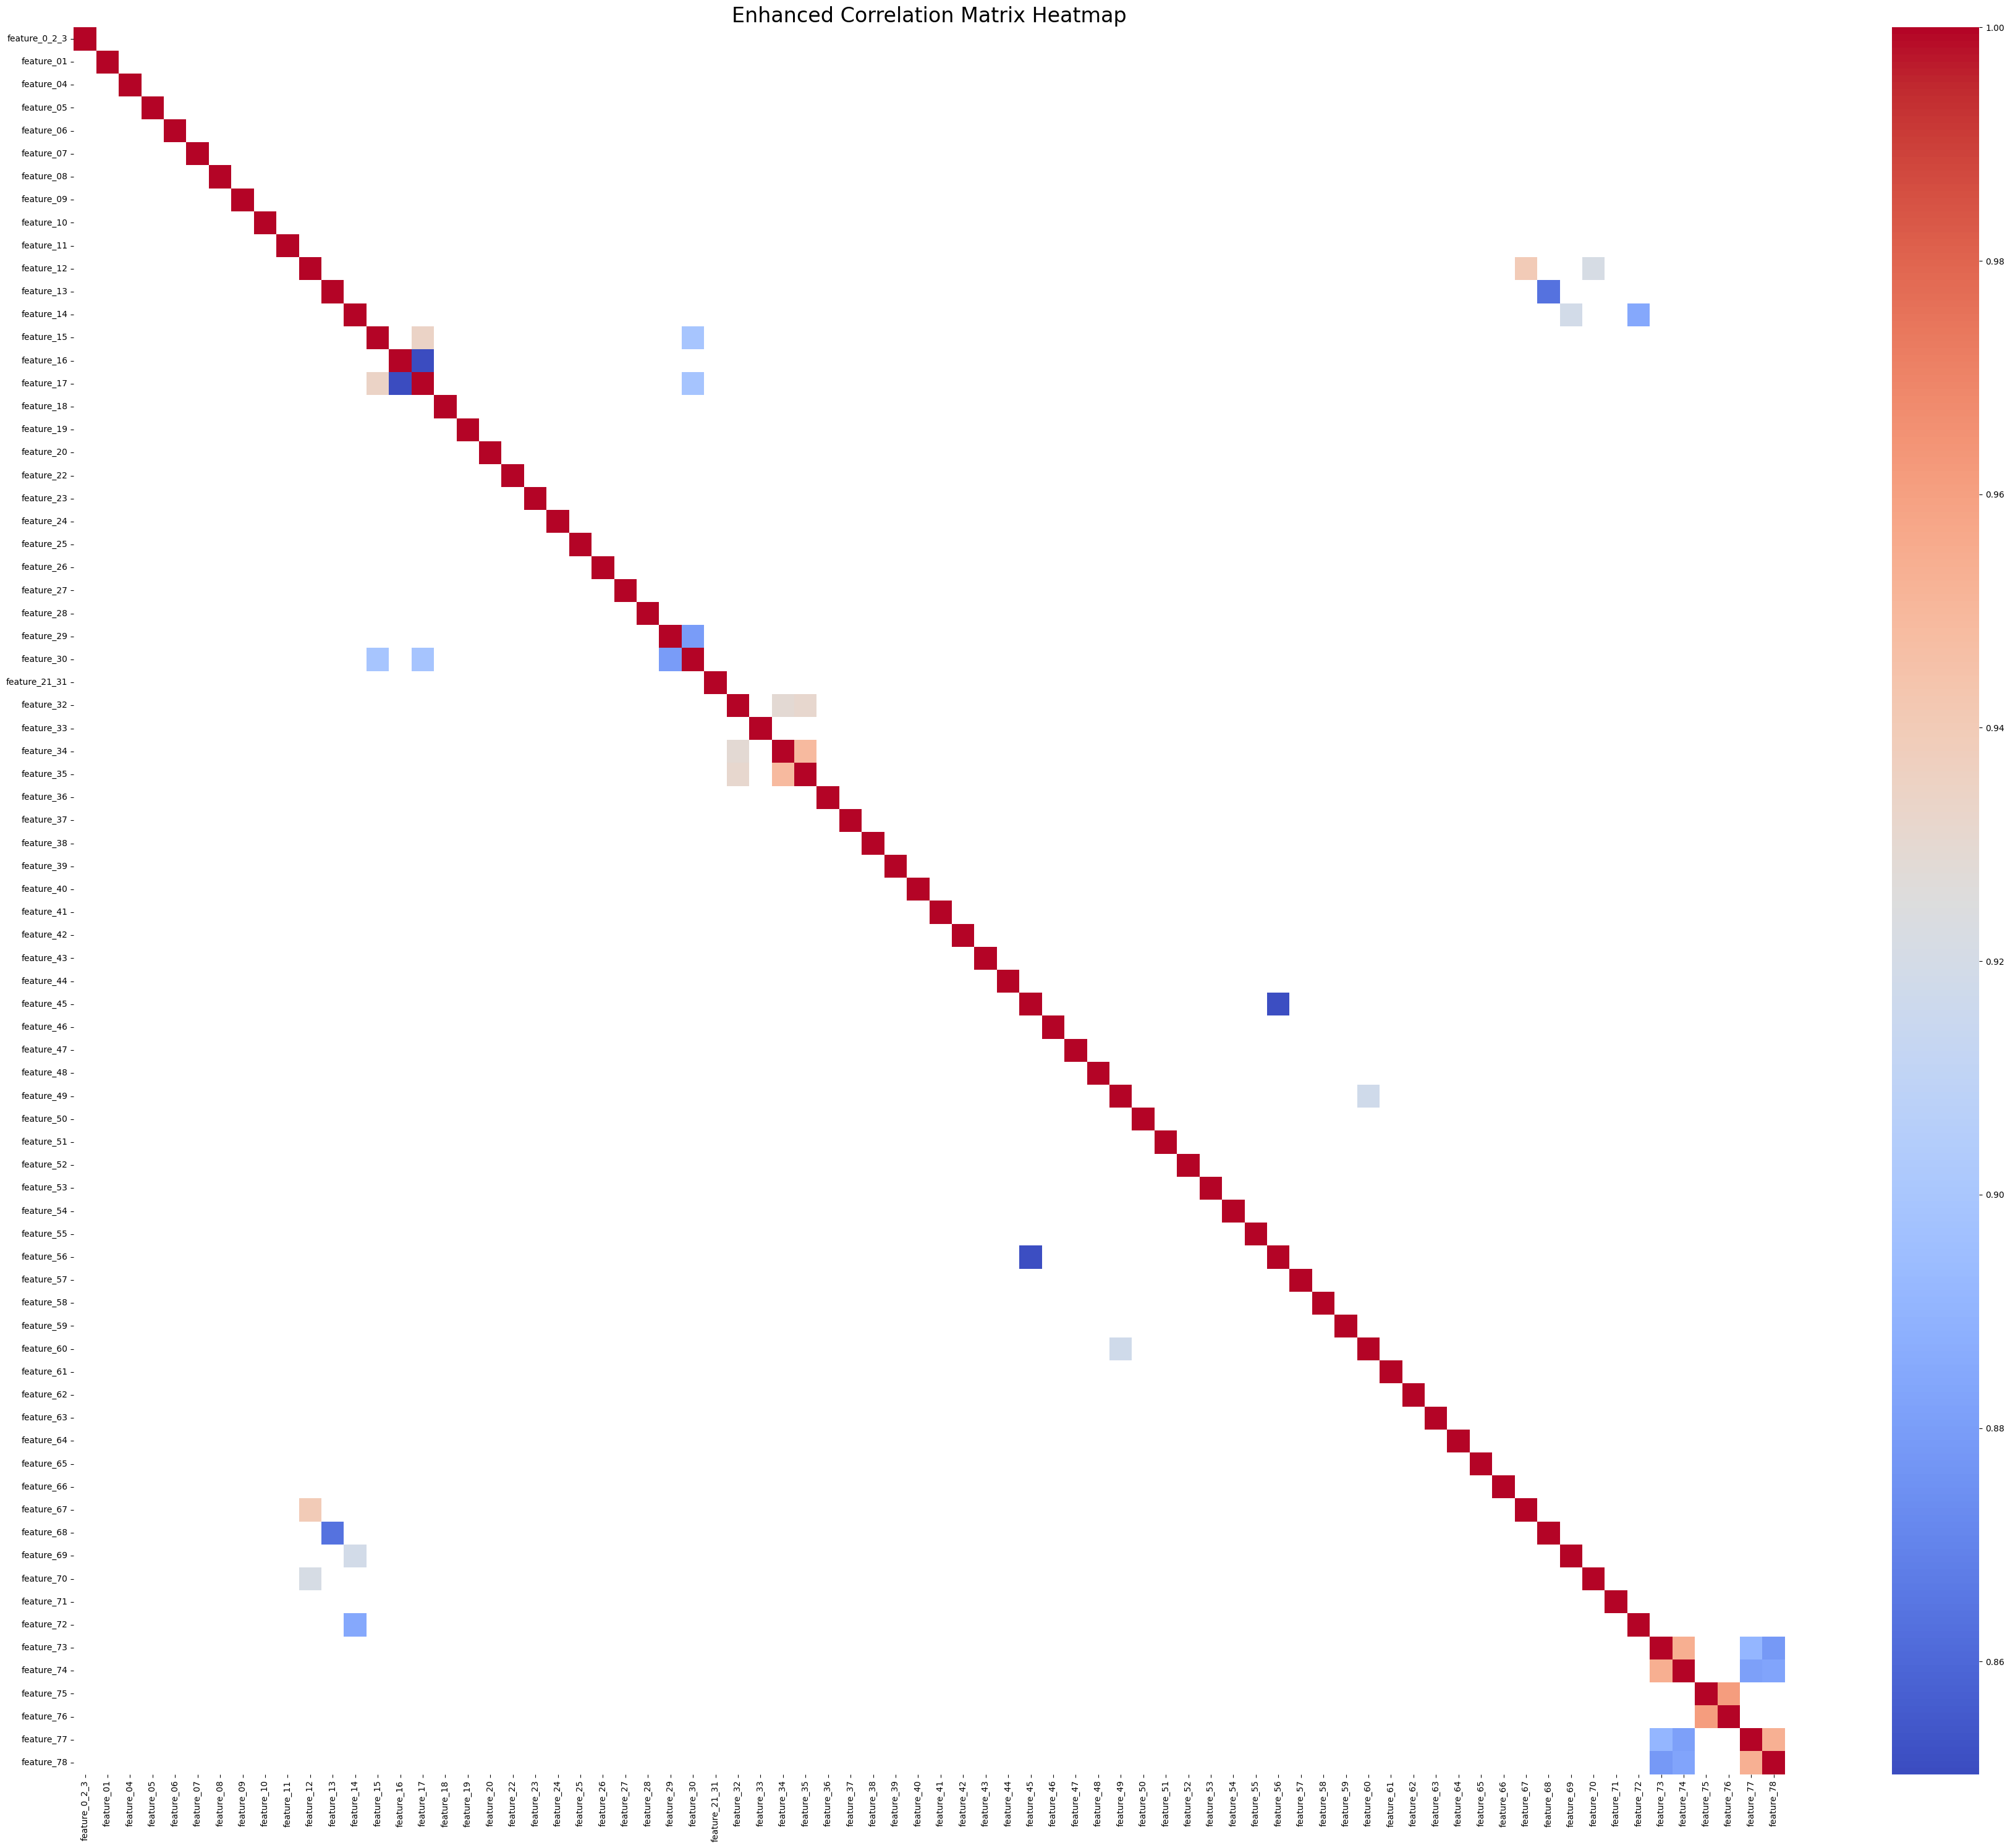

In [67]:
plt.figure(figsize=(36, 30))
sns.heatmap(
    corrMatrix, 
    annot=False, 
    cmap='coolwarm', 
    cbar=True, 
    mask=corrMatrix.abs() < 0.85
)
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.title('Enhanced Correlation Matrix Heatmap', fontsize=24)
plt.tight_layout()
plt.savefig("./Plots/Correlation Matrix/85+.png")
plt.show()
plt.close()

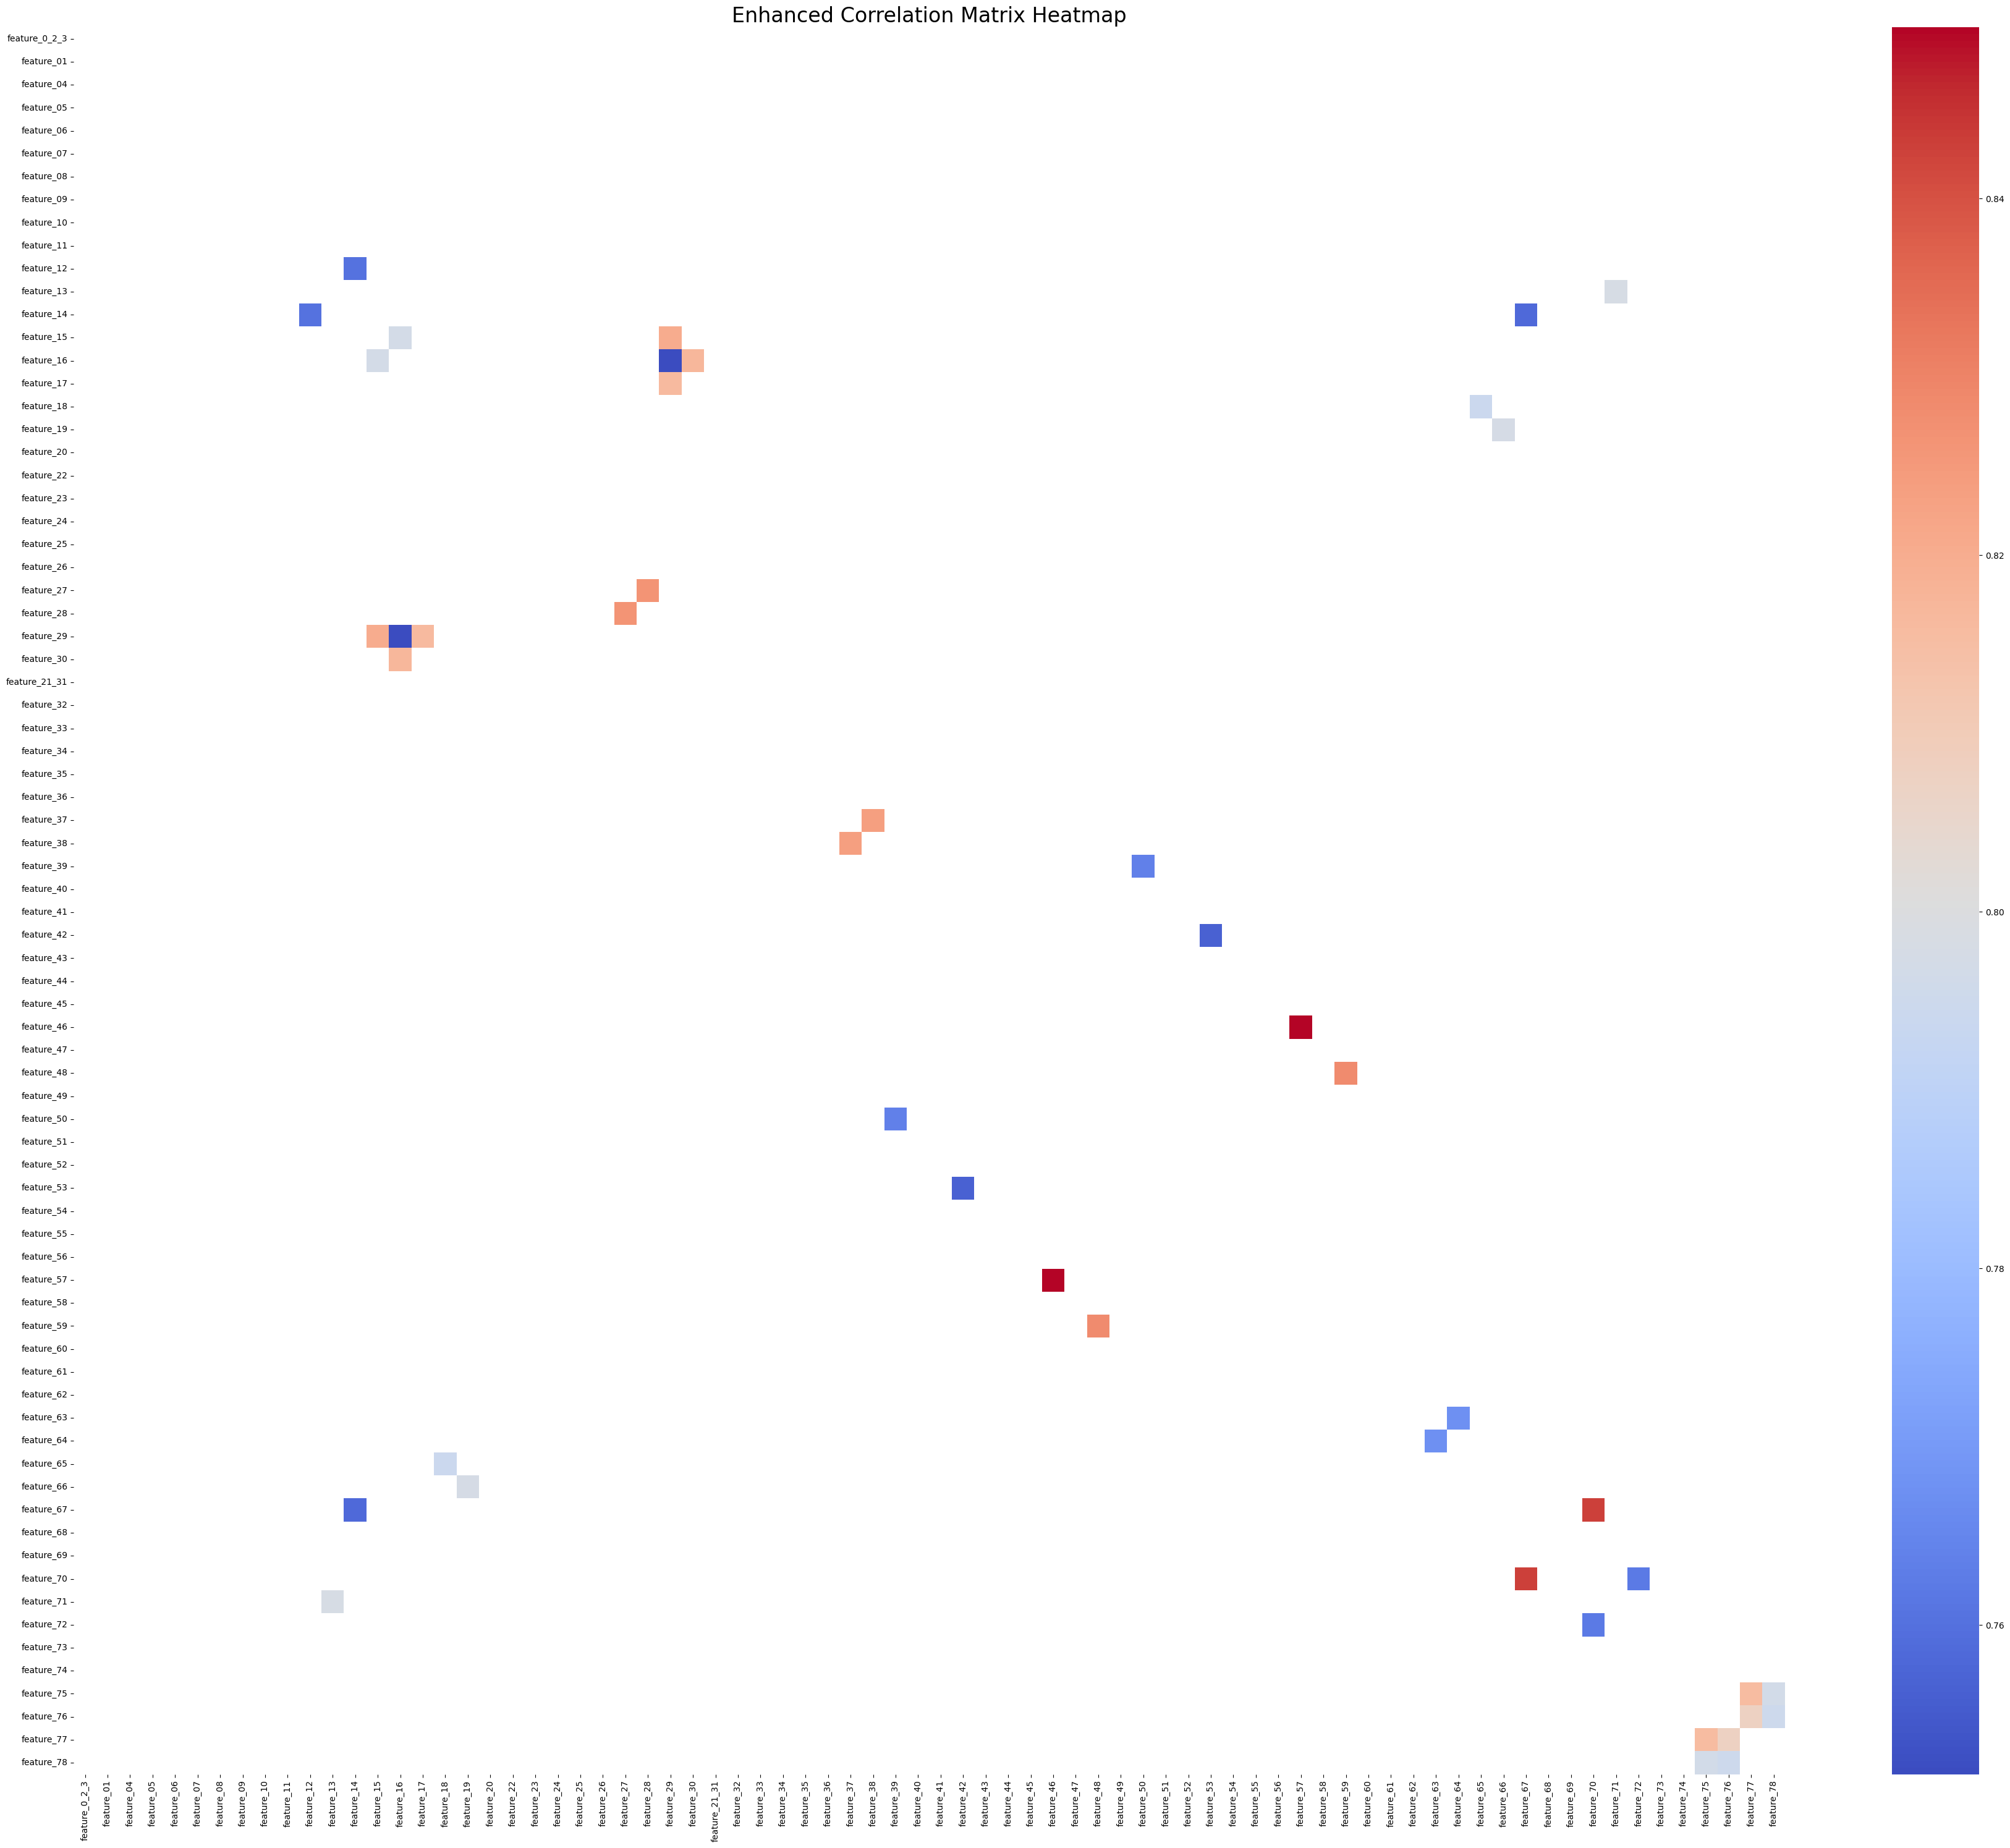

In [68]:
plt.figure(figsize=(36, 30))
mask = (corrMatrix.abs() < 0.75) | (corrMatrix.abs() > 0.85)
sns.heatmap(
    corrMatrix, 
    annot=False, 
    cmap='coolwarm', 
    cbar=True, 
    mask=mask
)
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.title('Enhanced Correlation Matrix Heatmap', fontsize=24)
plt.tight_layout()
plt.savefig("./Plots/Correlation Matrix/75-85.png")
plt.show()
plt.close()

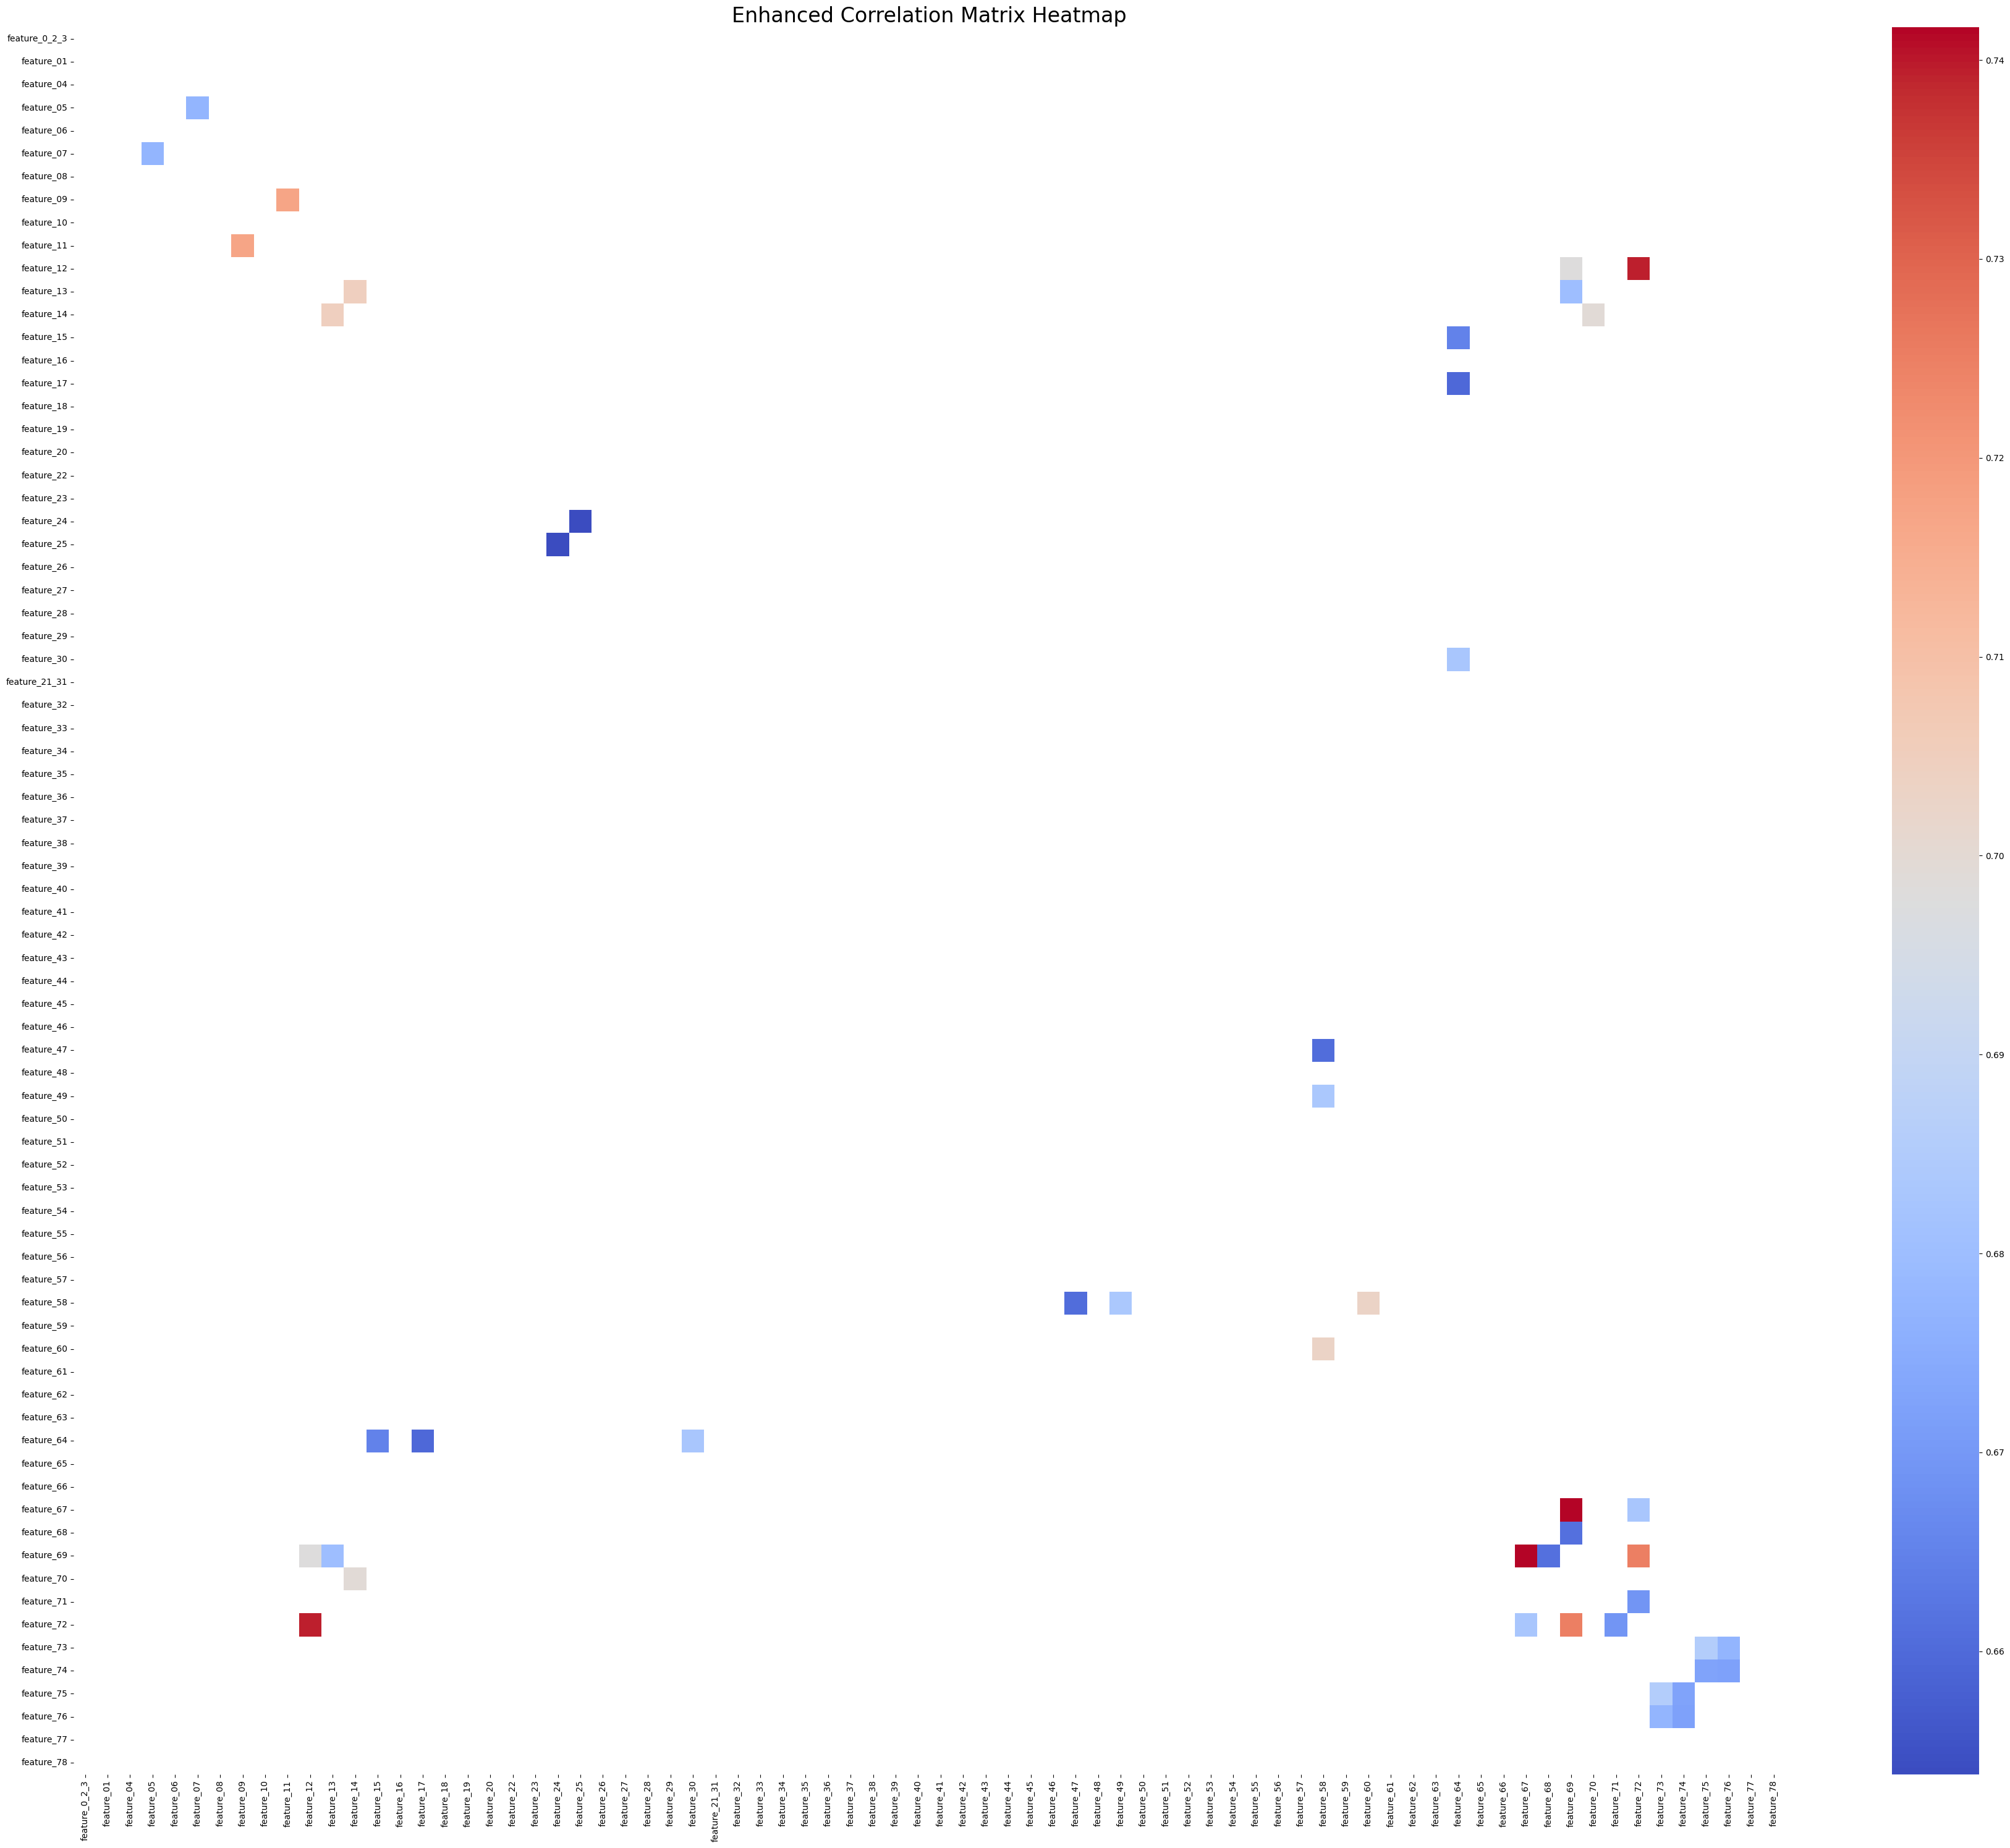

In [69]:
plt.figure(figsize=(36, 30))
mask = (corrMatrix.abs() < 0.65) | (corrMatrix.abs() > 0.75)
sns.heatmap(
    corrMatrix, 
    annot=False, 
    cmap='coolwarm', 
    cbar=True, 
    mask=mask
)
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.title('Enhanced Correlation Matrix Heatmap', fontsize=24)
plt.tight_layout()
plt.savefig("./Plots/Correlation Matrix/65-75.png")
plt.show()
plt.close()

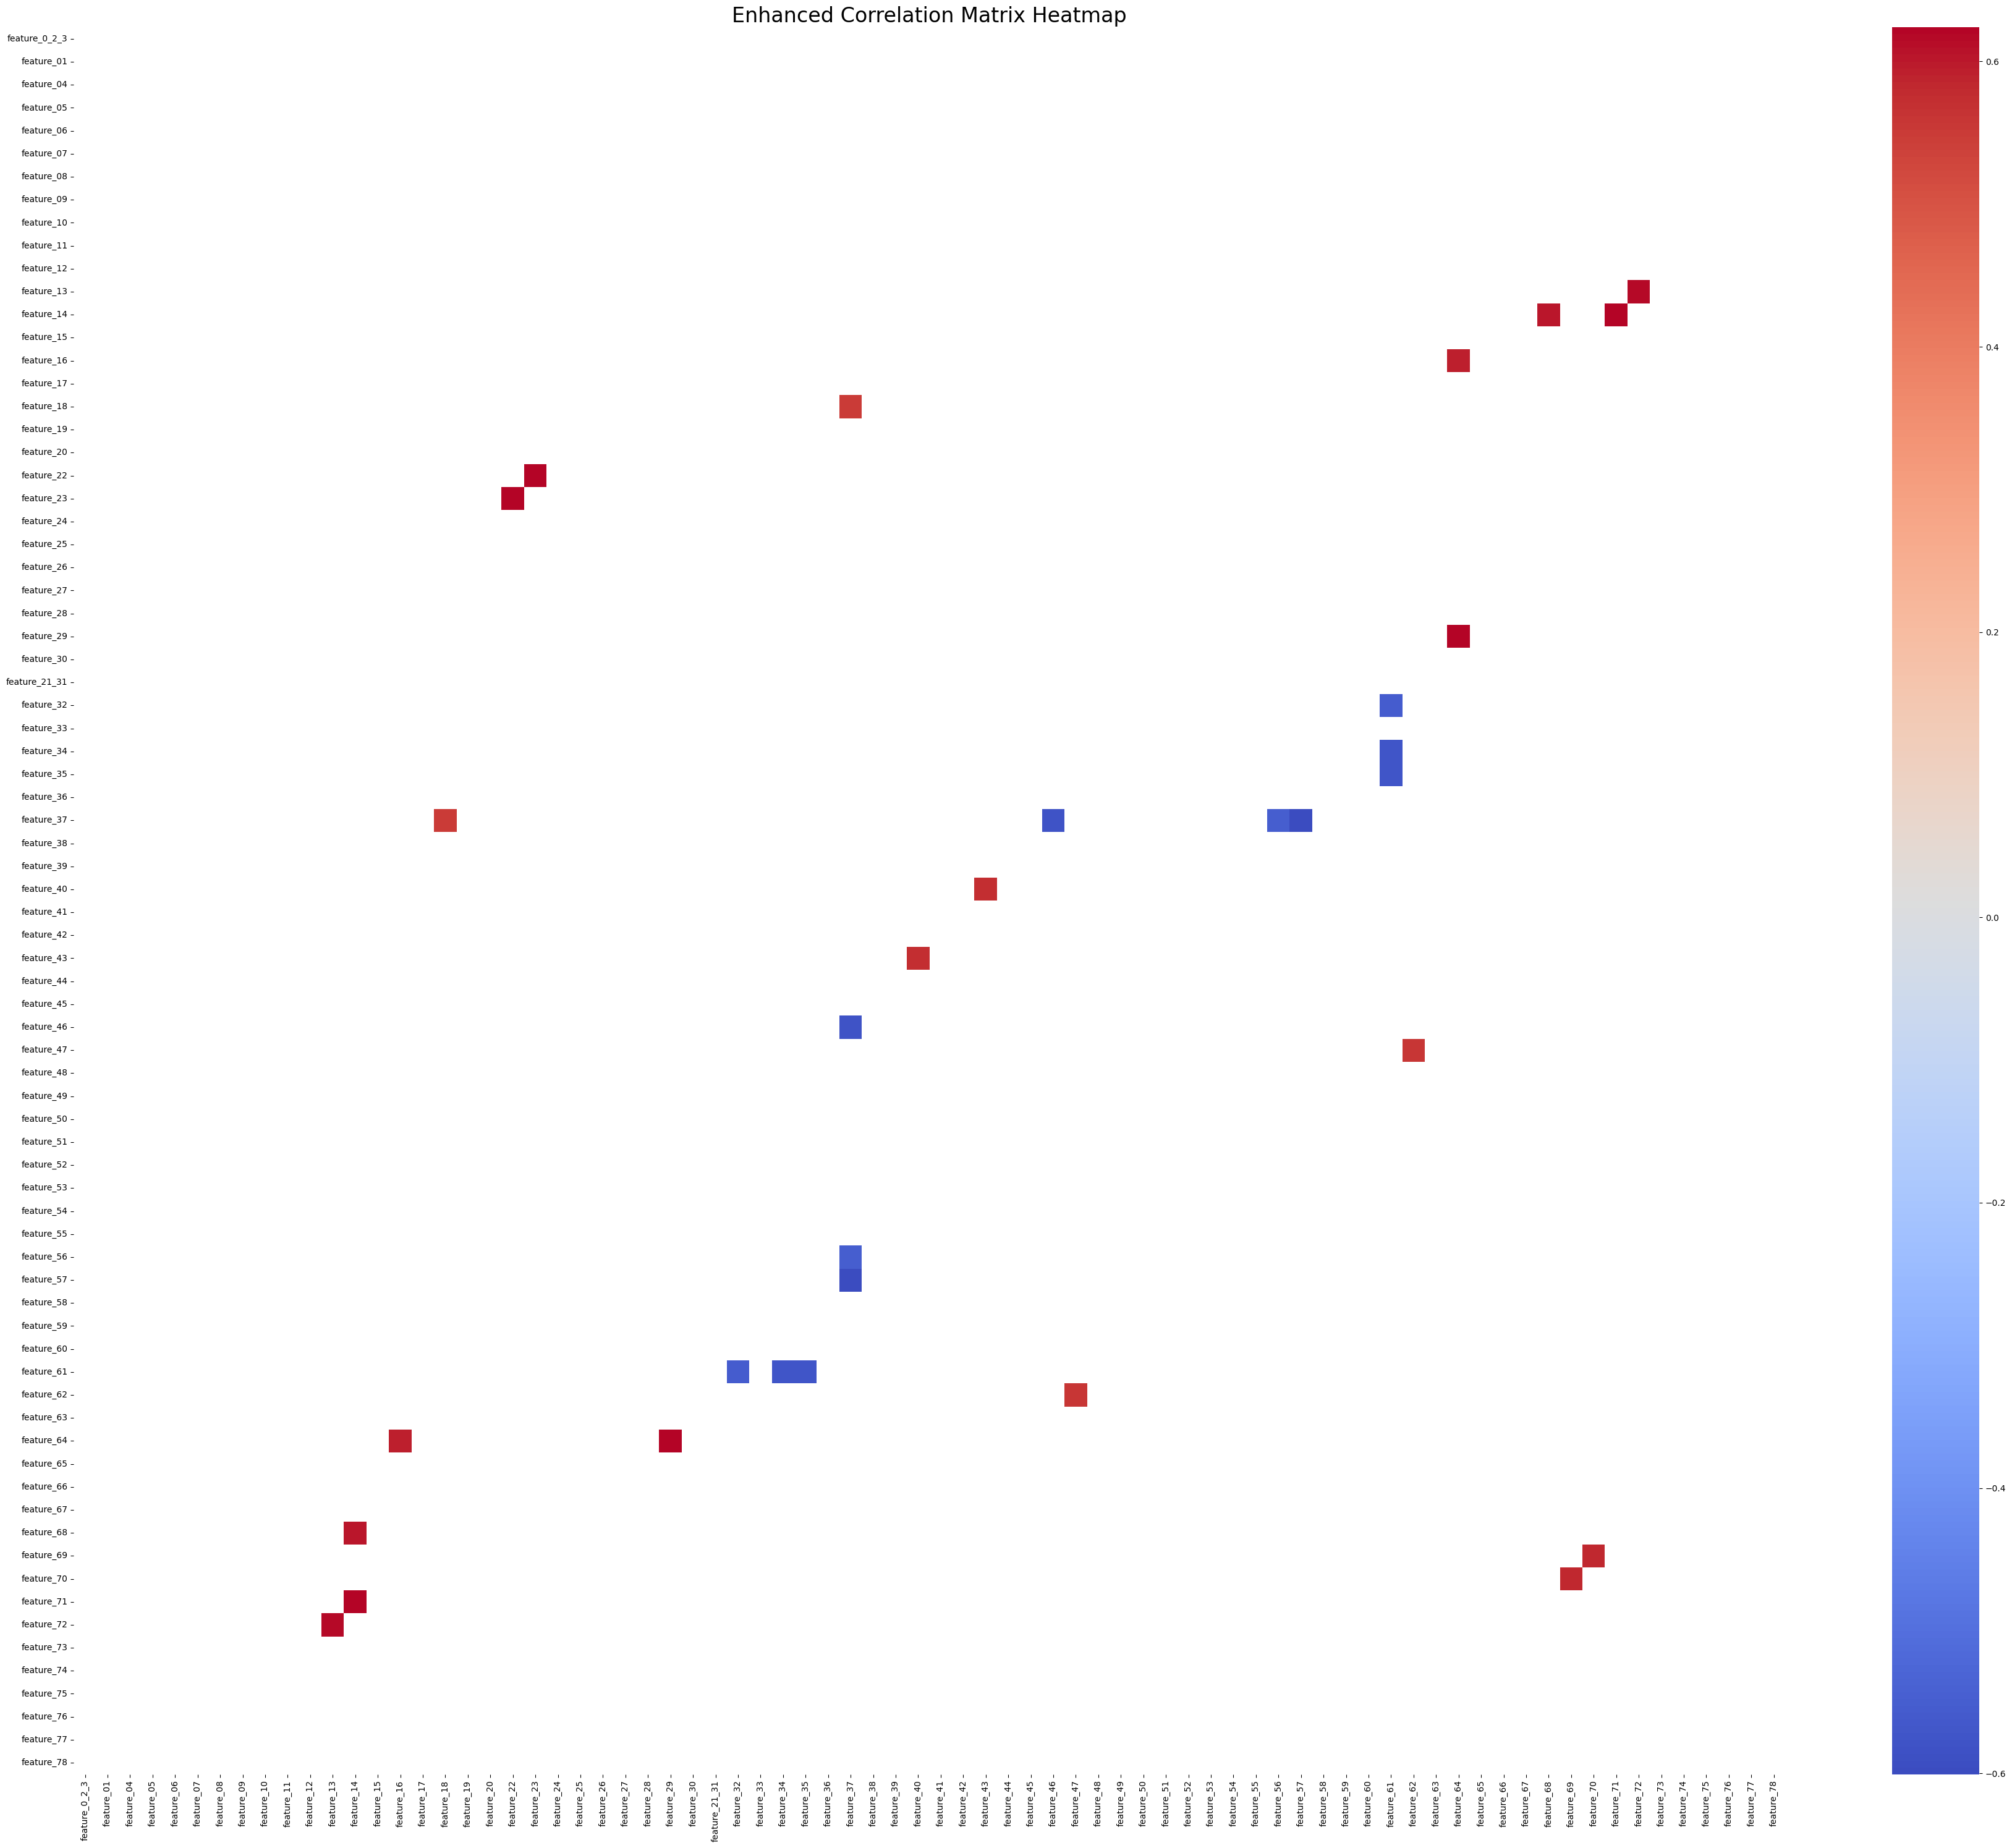

In [70]:
plt.figure(figsize=(36, 30))
mask = (corrMatrix.abs() < 0.55) | (corrMatrix.abs() > 0.65)
sns.heatmap(
    corrMatrix, 
    annot=False, 
    cmap='coolwarm', 
    cbar=True, 
    mask=mask
)
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.title('Enhanced Correlation Matrix Heatmap', fontsize=24)
plt.tight_layout()
plt.savefig("./Plots/Correlation Matrix/55-65.png")
plt.show()
plt.close()

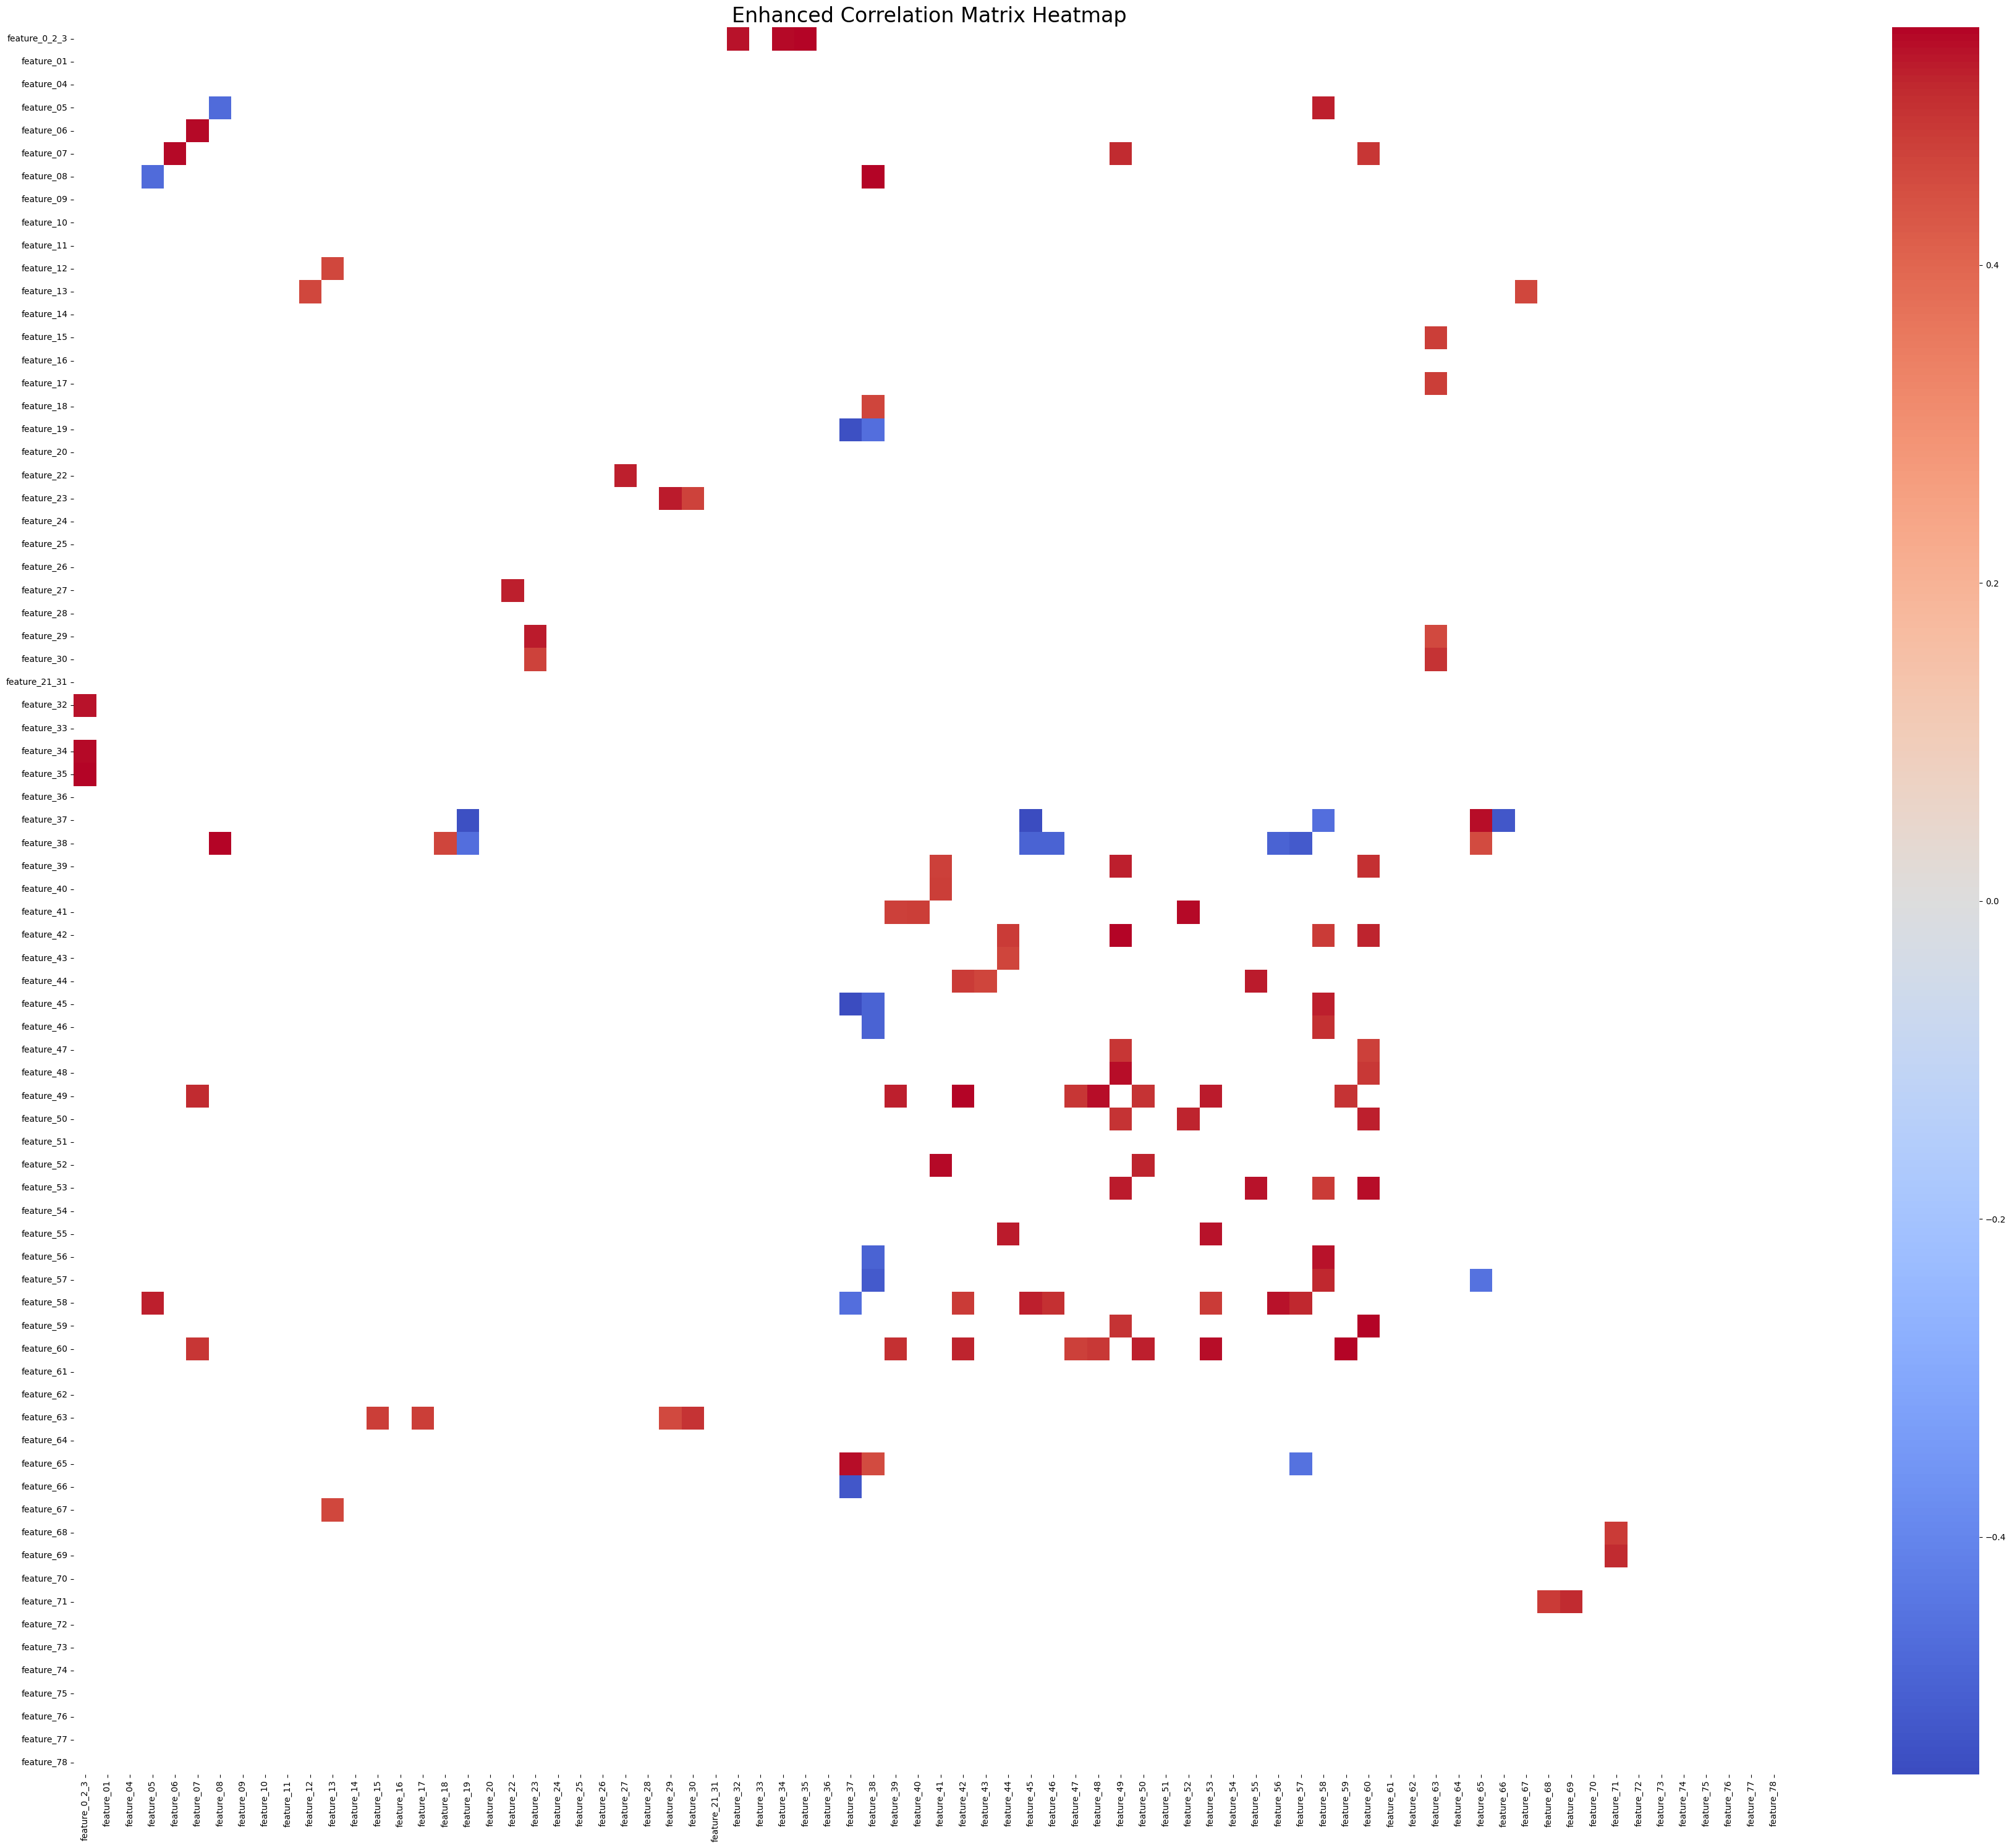

In [71]:
plt.figure(figsize=(36, 30))
mask = (corrMatrix.abs() < 0.45) | (corrMatrix.abs() > 0.55)
sns.heatmap(
    corrMatrix, 
    annot=False, 
    cmap='coolwarm', 
    cbar=True, 
    mask=mask
)
plt.xticks(fontsize=10)  
plt.yticks(fontsize=10)  
plt.title('Enhanced Correlation Matrix Heatmap', fontsize=24)
plt.tight_layout()
plt.savefig("./Plots/Correlation Matrix/45-55.png")
plt.show()
plt.close()

In [76]:
sampleStandardFeatures = sampleStandardFeatures.dropna()

In [77]:
pca = PCA(n_components=0.99)
dfPCA = pca.fit_transform(sampleStandardFeatures)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Number of components:", pca.n_components_)

Explained Variance Ratio: [0.11965212 0.10066494 0.08122603 0.06457517 0.05696952 0.05031833
 0.03684624 0.03258071 0.031235   0.02582089 0.02348547 0.02150662
 0.01946642 0.01876134 0.01777107 0.01610923 0.01425443 0.01352586
 0.01340082 0.01271157 0.0125574  0.01165875 0.01133488 0.01077712
 0.00999347 0.00987667 0.00969276 0.00935789 0.00821757 0.00764077
 0.00751039 0.00710423 0.00690825 0.00618297 0.00602575 0.00596596
 0.00572754 0.00504    0.00491416 0.00471813 0.00464403 0.00448209
 0.00404748 0.00382785 0.00354412 0.00336275 0.00319679 0.00291883
 0.00284693 0.00279882 0.00278019 0.0026819  0.00222933 0.00216096
 0.00189241 0.00182468 0.0018095  0.00177539 0.00174349 0.00160296
 0.00148009 0.00138921]
Number of components: 62


In [78]:
component_weights = pd.DataFrame(pca.components_, columns=sampleStandardFeatures.columns)
print(component_weights)

    feature_0_2_3  feature_01  feature_04  feature_05  feature_06  feature_07  \
0        0.000485    0.018341    0.024092    0.139424    0.068496    0.125702   
1       -0.080397    0.011828    0.015201    0.100983    0.053937    0.093254   
2        0.058942    0.026090    0.024000    0.110132    0.071914    0.121171   
3       -0.043875   -0.006631   -0.017596   -0.002559   -0.096744   -0.094888   
4        0.028564   -0.018093    0.014485   -0.054089    0.088629    0.055108   
..            ...         ...         ...         ...         ...         ...   
57      -0.005093    0.026045   -0.015698   -0.044959   -0.000694    0.052018   
58       0.003114   -0.002972    0.009276    0.001627    0.010696   -0.030212   
59       0.001658    0.050561   -0.056249   -0.487798   -0.180852    0.498815   
60       0.010775    0.033760   -0.021454   -0.125024   -0.036322    0.118659   
61       0.027813    0.004737    0.003601    0.002717    0.001126   -0.008969   

    feature_08  feature_09 